In [1]:
# https://langchain-ai.github.io/langgraph/tutorials/plan-and-execute/plan-and-execute/

from dotenv import load_dotenv

from langchain_ollama import ChatOllama
from langgraph.graph import MessagesState, StateGraph, START, END
from langgraph.prebuilt import create_react_agent
# from langgraph.types import Command, interrupt

load_dotenv()

C:\Users\kevin\AppData\Roaming\Python\Python314\site-packages\langchain_core\_api\deprecation.py:26: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1
C:\Users\kevin\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
import random
from typing import Annotated, List, Tuple
from typing_extensions import TypedDict

from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool

In [3]:
# llm = ChatAnthropic(model="claude-3-5-sonnet-latest")
# llm = ChatOllama(model="mistral-small:latest", temperature=0, base_url = "http://192.168.1.203:11434")
# llm = ChatOllama(model="qwq:latest", temperature=0, base_url = "http://192.168.1.203:11434")
llm = ChatOllama(model="qwen3:8b")

In [4]:
from langchain_community.tools.tavily_search import TavilySearchResults

tools = [TavilySearchResults(max_results=3)]

C:\Users\kevin\AppData\Local\Temp\ipykernel_30568\2518516040.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tools = [TavilySearchResults(max_results=3)]


In [5]:
prompt = "You are a helpful assistant."
agent_executor = create_react_agent(llm, tools, prompt=prompt)

C:\Users\kevin\AppData\Local\Temp\ipykernel_30568\3454542602.py:2: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent_executor = create_react_agent(llm, tools, prompt=prompt)


In [6]:
agent_executor.invoke({"messages": [("user", "who is the winnner of the us open")]})

{'messages': [HumanMessage(content='who is the winnner of the us open', additional_kwargs={}, response_metadata={}, id='19c2a5dc-2c2d-4e42-968a-bd73af59efca'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3:8b', 'created_at': '2026-01-19T02:36:43.7823456Z', 'done': True, 'done_reason': 'stop', 'total_duration': 153519799600, 'load_duration': 4136406000, 'prompt_eval_count': 189, 'prompt_eval_duration': 29606630200, 'eval_count': 414, 'eval_duration': 119414945900, 'logprobs': None, 'model_name': 'qwen3:8b', 'model_provider': 'ollama'}, id='lc_run--019bd41a-45cc-7121-9785-a11ab03d088c-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'winner of the US Open'}, 'id': '58d32c11-2124-4cc4-82cc-8ab9effa9e2b', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 189, 'output_tokens': 414, 'total_tokens': 603}),
  ToolMessage(content='[{"title": "Golf US Open Winners List - Complete Championship History", "url": 

In [7]:
import operator

class PlanExecute(TypedDict):
    input: str
    plan: List[str]
    past_steps: Annotated[List[Tuple], operator.add]
    response: str

In [8]:
from pydantic import BaseModel, Field


class Plan(BaseModel):
    """Plan to follow in future"""

    steps: List[str] = Field(
        description="different steps to follow, should be in sorted order"
    )

In [9]:
from langchain_core.prompts import ChatPromptTemplate

planner_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """For the given objective, come up with a simple step by step plan. \
This plan should involve individual tasks, that if executed correctly will yield the correct answer. Do not add any superfluous steps. \
The result of the final step should be the final answer. Make sure that each step has all the information needed - do not skip steps.""",
        ),
        ("placeholder", "{messages}"),
    ]
)
planner = planner_prompt | llm.with_structured_output(Plan)

In [10]:
planner.invoke(
    {
        "messages": [
            ("user", "what is the hometown of the current Australia open winner?")
        ]
    }
)

Plan(steps=['Identify the most recent Australian Open champion (2023).', "Determine the hometown of the 2023 Australian Open men's singles winner, Novak Djokovic, which is Belgrade, Serbia."])

In [11]:
from typing import Union


class Response(BaseModel):
    """Response to user."""

    response: str


class Act(BaseModel):
    """Action to perform."""

    action: Union[Response, Plan] = Field(
        description="Action to perform. If you want to respond to user, use Response. "
        "If you need to further use tools to get the answer, use Plan."
    )


replanner_prompt = ChatPromptTemplate.from_template(
    """For the given objective, come up with a simple step by step plan. \
This plan should involve individual tasks, that if executed correctly will yield the correct answer. Do not add any superfluous steps. \
The result of the final step should be the final answer. Make sure that each step has all the information needed - do not skip steps.

Your objective was this:
{input}

Your original plan was this:
{plan}

You have currently done the follow steps:
{past_steps}

Update your plan accordingly. If no more steps are needed and you can return to the user, then respond with that. Otherwise, fill out the plan. Only add steps to the plan that still NEED to be done. Do not return previously done steps as part of the plan."""
)


replanner = replanner_prompt | llm.with_structured_output(Act)

In [12]:
from typing import Literal
from langgraph.graph import END


async def execute_step(state: PlanExecute):
    plan = state["plan"]
    plan_str = "\n".join(f"{i+1}. {step}" for i, step in enumerate(plan))
    task = plan[0]
    task_formatted = f"""For the following plan:
{plan_str}\n\nYou are tasked with executing step {1}, {task}."""
    agent_response = await agent_executor.ainvoke(
        {"messages": [("user", task_formatted)]}
    )
    return {
        "past_steps": [(task, agent_response["messages"][-1].content)],
    }


async def plan_step(state: PlanExecute):
    plan = await planner.ainvoke({"messages": [("user", state["input"])]})
    return {"plan": plan.steps}


async def replan_step(state: PlanExecute):
    output = await replanner.ainvoke(state)
    if isinstance(output.action, Response):
        return {"response": output.action.response}
    else:
        return {"plan": output.action.steps}


def should_end(state: PlanExecute):
    if "response" in state and state["response"]:
        return END
    else:
        return "agent"

In [ ]:
from langgraph.graph import StateGraph, START

workflow = StateGraph(PlanExecute)
workflow.add_node("planner", plan_step)     # Add the plan node
workflow.add_node("agent", execute_step)    # Add the execution step
workflow.add_node("replan", replan_step)    # Add a replan node
workflow.add_edge(START, "planner")
workflow.add_edge("planner", "agent")       # From plan we go to agent
workflow.add_edge("agent", "replan")        # From agent, we replan

workflow.add_conditional_edges(
    "replan",           # 1. 시작 노드(Starting Node)
    # Next, we pass in the function that will determine which node is called next.
    should_end,         # 2. 조건 함수(Condition Function) : state를 보고 다음 갈 곳의 '이름'을 반환
    ["agent", END],     # 3. 경로 지도(Path Map)
)

# Finally, we compile it!
# This compiles it into a LangChain Runnable,
# meaning you can use it as you would any other runnable
app = workflow.compile()

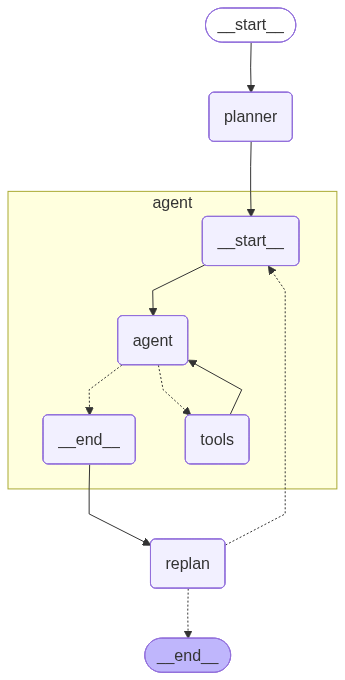

In [14]:
from IPython.display import Image, display

display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [15]:
config = {"recursion_limit": 500}
inputs = {"input": "what is the hometown of the mens 2024 Australia open winner?"}
async for event in app.astream(inputs, config=config):
    for k, v in event.items():
        if k != "__end__":
            print(v)

{'plan': ["Identify the winner of the men's singles title at the 2024 Australia Open by checking official tournament results or reputable sports news sources.", 'Determine the hometown or place of birth of the identified winner by referencing biographical information from credible sources (e.g., official player profiles, sports databases, or news articles).']}
{'past_steps': [("Identify the winner of the men's singles title at the 2024 Australia Open by checking official tournament results or reputable sports news sources.", "The winner of the men's singles title at the 2024 Australia Open was **Jannik Sinner**. He defeated Daniil Medvedev in the final with a score of 3–6, 3–6, 6–4, 6–4, 6–3. This marked Sinner's first Grand Slam singles title and the first Italian man to win an Australian Open singles title in the Open Era.")]}
{'plan': ['Determine the hometown or place of birth of the identified winner (Jannik Sinner) by referencing biographical information from credible sources (e.g